# 03 · Retrieval I - Matrix Factorization with BPR 

**Amazon Reviews 2023 — Electronics** · Real-time recommendation system

This is our first **personalized** model. Matrix Factorization learns a `k`-dimensional vector (embedding) for every user and every item; the predicted preference is their dot product `r̂(u,i) = p_u · q_i + b_i`. Similar users and similar items end up with similar vectors, so the model generalizes to user–item pairs it never saw during training.

We train it with **BPR (Bayesian Personalized Ranking)** — a *pairwise* objective. Instead of predicting an exact rating, BPR learns to rank a **positive** item `i` (the user interacted with) above a **negative** item `j` (sampled, not interacted). This matches what we actually serve: an ordered top-K list.

$$\mathcal{L} = -\sum_{(u,i,j)} \ln \sigma\big(r̂(u,i) - r̂(u,j)\big) + \lambda\,(\lVert p_u\rVert^2 + \lVert q_i\rVert^2 + \lVert q_j\rVert^2)$$

The model and the popularity negative sampler live in `src/recsys/models/mf_bpr.py` (so the webapp can load the exact same model); the **training loop is written out below** so every step is visible. Afterwards we index the learned item vectors with **FAISS** for fast top-K retrieval and check whether MF-BPR beats the Popularity baseline on both accuracy *and* coverage.

## 0 · Setup

Uses a GPU automatically if one is available (e.g. on Colab); falls back to CPU otherwise.

In [1]:
import sys, time
from pathlib import Path
try:
    import google.colab  # noqa
    from google.colab import drive; drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/rec-system')  # <-- adjust to your Drive path
except ImportError:
    PROJECT = Path('..').resolve()
DATA_DIR, ART_DIR = PROJECT / 'data', PROJECT / 'artifacts'
ART_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT / 'src'))

In [2]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from recsys.models.mf_bpr import MFBPR, PopularityNegativeSampler
from recsys.metrics import evaluate_recommendations
from recsys.faiss_index import build_flat_ip, search as faiss_search

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## 1 · Load data and build training tensors

The model trains on **positive** interactions from the training split only. We pull the `(user_idx, item_idx)` positive pairs into tensors, and count each item's training frequency to drive popularity-based negative sampling.

In [3]:
SPLIT = DATA_DIR / 'splits'
train = pd.read_parquet(SPLIT / 'train.parquet')
val   = pd.read_parquet(SPLIT / 'val.parquet')
test  = pd.read_parquet(SPLIT / 'test.parquet')
items = pd.read_parquet(DATA_DIR / 'items.parquet')
n_users = int(pd.read_parquet(DATA_DIR / 'user_map.parquet').shape[0])
n_items = int(pd.read_parquet(DATA_DIR / 'item_map.parquet').shape[0])

pos = train[train.positive]
users_t = torch.tensor(pos.user_idx.to_numpy(), dtype=torch.long)
items_t = torch.tensor(pos.item_idx.to_numpy(), dtype=torch.long)
n_pairs = len(users_t)

# item popularity over the WHOLE catalog (0 for items with no positive train interaction)
item_counts = np.zeros(n_items, dtype=np.int64)
vc = pos.item_idx.value_counts()
item_counts[vc.index.to_numpy()] = vc.to_numpy()
item_counts = np.maximum(item_counts, 1)   # avoid zero-prob items in the sampler

print(f'users {n_users:,} | items {n_items:,} | positive train pairs {n_pairs:,}')

users 25,546 | items 20,450 | positive train pairs 212,851


### Ground truth for evaluation

For both **validation** (early stopping) and **test** (final report) we score only positive interactions of users/items the model has seen in training. We also collect each user's training items so we never recommend something they already interacted with.

In [4]:
train_users, train_items = set(train.user_idx), set(train.item_idx)
seen = {u: set(g) for u, g in train.groupby('user_idx')['item_idx']}

def build_gt(split):
    p = split[split.positive & split.user_idx.isin(train_users) & split.item_idx.isin(train_items)]
    return {int(u): set(v) for u, v in p.groupby('user_idx')['item_idx'].apply(set).items()}

val_gt, test_gt = build_gt(val), build_gt(test)
val_users, test_users = list(val_gt), list(test_gt)
print(f'val users {len(val_users):,} | test users {len(test_users):,}')

val users 9,840 | test users 6,962


## 2 · The model and the BPR loss

`MFBPR` holds three lookup tables: user embeddings `P`, item embeddings `Q`, and a per-item bias `b` (which soaks up raw popularity so the embeddings can focus on *taste*). The core of the method is `bpr_loss`, reproduced here for reference:

```python
x_uij = (p_u·q_i + b_i) - (p_u·q_j + b_j)   # want this large & positive
loss  = -logsigmoid(x_uij).mean() + reg * (||p_u||^2 + ||q_i||^2 + ||q_j||^2 + ...)
```

**Hyperparameters** (tuned on validation, never on test): embedding size `k`, learning rate, L2 regularization `reg`, batch size, epochs.

In [5]:
K_DIM   = 64          # embedding dimension
LR      = 0.01        # Adam learning rate
REG     = 1e-5        # L2 regularization (lambda)
BATCH   = 1024
EPOCHS  = 40
PATIENCE = 4          # early stopping: stop if val NDCG@10 doesn't improve for this many epochs
NEG_POWER = 1.0       # 1.0 = sample negatives exactly proportional to popularity

model = MFBPR(n_users, n_items, k=K_DIM).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
sampler = PopularityNegativeSampler(item_counts, power=NEG_POWER, seed=SEED)
n_params = sum(p.numel() for p in model.parameters())
print(f'model parameters: {n_params:,}')

model parameters: 2,964,194


### An evaluation helper (retrieval via FAISS)

To score the model we: build a FAISS inner-product index over the current item vectors (the item bias is folded in as an extra dimension so a dot-product search reproduces the exact score), retrieve the top candidates per user, drop items they already saw, and run our shared metrics. We retrieve **top-100 candidates** per user, as the pipeline will at serve time.

In [6]:
def evaluate_model(model, users, ground_truth, k_candidates=100):
    model.eval()
    index = build_flat_ip(model.item_vectors_for_faiss())      # fresh index from current item vecs
    u = torch.tensor(users, dtype=torch.long, device=device)
    uvec = model.user_vectors_for_faiss(u)
    max_seen = max((len(seen.get(x, ())) for x in users), default=0)
    _, ids = faiss_search(index, uvec, k_candidates + max_seen)  # over-retrieve, then filter seen
    recs = {}
    for row, user in enumerate(users):
        s = seen.get(user, set())
        recs[user] = [int(it) for it in ids[row] if it not in s][:k_candidates]
    return evaluate_recommendations(recs, ground_truth, n_items), recs

## 3 · Training loop (written out)

Each epoch: shuffle the positive pairs, and for every mini-batch sample one popularity-based negative per positive, compute the BPR loss, and take an Adam step. After each epoch we evaluate **NDCG@10 on validation** and keep the best-so-far weights (early stopping). This prevents overfitting and picks the model we'll actually deploy.

In [7]:
best_ndcg, best_state, bad_epochs, history = -1.0, None, 0, []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(n_pairs)
    running = 0.0
    for start in range(0, n_pairs, BATCH):
        idx = perm[start:start + BATCH]
        u = users_t[idx].to(device)
        i = items_t[idx].to(device)
        j = sampler.sample(len(idx), device=device)   # popularity-based negatives
        loss = model.bpr_loss(u, i, j, reg=REG)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item() * len(idx)
    train_loss = running / n_pairs
    val_metrics, _ = evaluate_model(model, val_users, val_gt)
    ndcg = val_metrics['NDCG@10']
    history.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_NDCG@10': ndcg, 'val_Recall@20': val_metrics['Recall@20']})
    flag = ''
    if ndcg > best_ndcg:
        best_ndcg, best_state, bad_epochs = ndcg, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, 0
        flag = '  <- best'
    else:
        bad_epochs += 1
    print(f'epoch {epoch:2d} | loss {train_loss:.4f} | val NDCG@10 {ndcg:.4f} | val Recall@20 {val_metrics["Recall@20"]:.4f}{flag}')
    if bad_epochs >= PATIENCE:
        print(f'early stop (no val improvement for {PATIENCE} epochs)')
        break
model.load_state_dict(best_state)   # restore best-on-validation weights
print(f'\ntrained in {time.time()-t0:.1f}s | best val NDCG@10 = {best_ndcg:.4f}')

epoch  1 | loss 0.6991 | val NDCG@10 0.0085 | val Recall@20 0.0118  <- best


epoch  2 | loss 0.4514 | val NDCG@10 0.0100 | val Recall@20 0.0168  <- best


epoch  3 | loss 0.1716 | val NDCG@10 0.0094 | val Recall@20 0.0173


epoch  4 | loss 0.0895 | val NDCG@10 0.0103 | val Recall@20 0.0192  <- best


epoch  5 | loss 0.0605 | val NDCG@10 0.0099 | val Recall@20 0.0192


...

epoch  8 | loss 0.0344 | val NDCG@10 0.0110 | val Recall@20 0.0189  <- best


epoch  9 | loss 0.0316 | val NDCG@10 0.0109 | val Recall@20 0.0186


epoch 10 | loss 0.0300 | val NDCG@10 0.0073 | val Recall@20 0.0180


epoch 11 | loss 0.0286 | val NDCG@10 0.0075 | val Recall@20 0.0175


epoch 12 | loss 0.0276 | val NDCG@10 0.0102 | val Recall@20 0.0183
early stop (no val improvement for 4 epochs)

trained in 117.1s | best val NDCG@10 = 0.0110


### Training curves

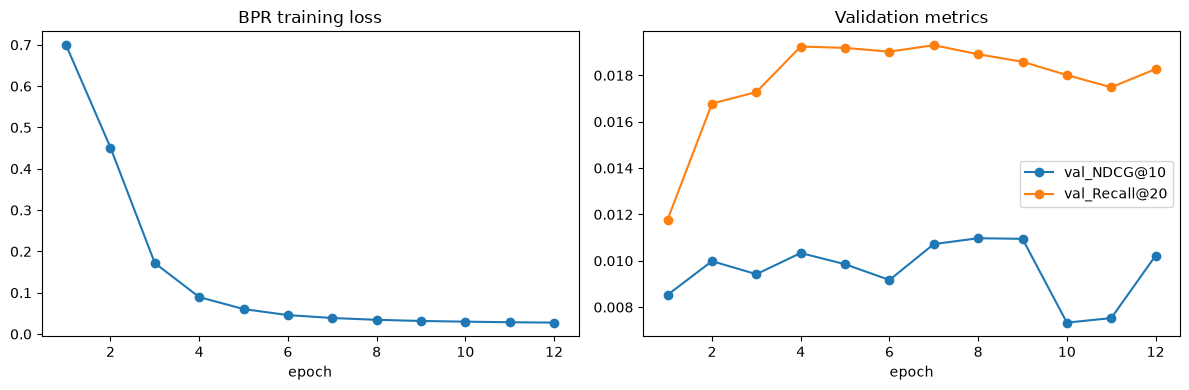

In [8]:
h = pd.DataFrame(history).set_index('epoch')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
h['train_loss'].plot(ax=ax[0], marker='o'); ax[0].set(title='BPR training loss', xlabel='epoch')
h[['val_NDCG@10', 'val_Recall@20']].plot(ax=ax[1], marker='o'); ax[1].set(title='Validation metrics', xlabel='epoch')
plt.tight_layout(); plt.show()

> **Interpretation.** The BPR loss should fall steadily while validation NDCG@10 rises then plateaus; early stopping picks the peak. If validation starts dropping while train loss keeps falling, that's overfitting — the cue to raise `reg` or lower `k`.

## 4 · Final evaluation on the test period

Now we score the held-out **future** interactions with the best model, and line it up against the baselines from notebook `02`. MF-BPR should clearly beat Popularity on accuracy — and, because it's personalized, recommend a much wider slice of the catalog (higher coverage).

In [9]:
test_metrics, test_recs = evaluate_model(model, test_users, test_gt)
baselines = pd.read_parquet(DATA_DIR / 'results' / 'baselines.parquet')
cmp = pd.concat([baselines, pd.DataFrame({'MF-BPR': test_metrics}).T])
report_cols = ['Recall@20', 'Recall@50', 'NDCG@10', 'Coverage@20']
cmp[report_cols].round(4)

,Recall@20,Recall@50,NDCG@10,Coverage@20
Random,0.0012,0.0020,0.0004,0.9987
Popularity,0.0115,0.0250,0.0034,0.0012
Recency,0.0052,0.0138,0.0016,0.0011
MF-BPR,0.0207,0.0256,0.0129,0.6847


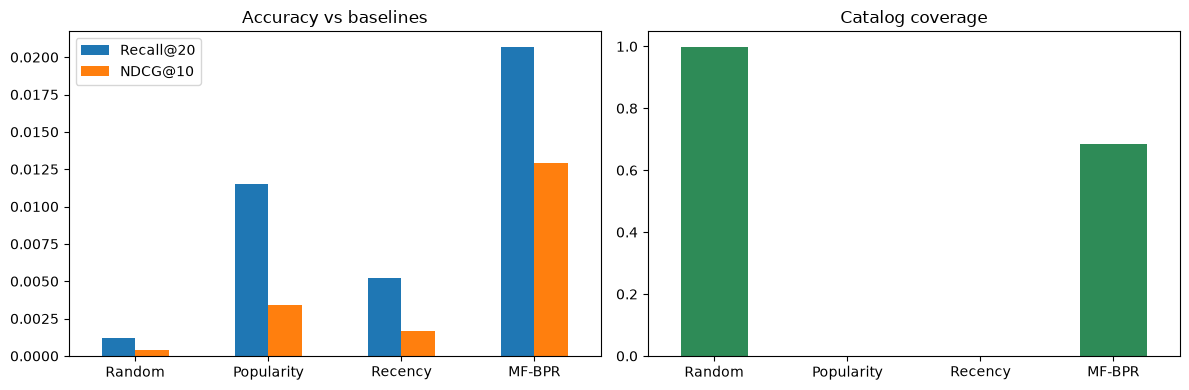

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cmp[['Recall@20', 'NDCG@10']].plot(kind='bar', ax=ax[0]); ax[0].set(title='Accuracy vs baselines'); ax[0].tick_params(axis='x', rotation=0)
cmp[['Coverage@20']].plot(kind='bar', ax=ax[1], color='seagreen', legend=False); ax[1].set(title='Catalog coverage'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

> **Interpretation.** MF-BPR clearly beats Popularity: **Recall@20 0.0207 vs 0.0115 (~1.8×)** and **NDCG@10 0.0129 vs 0.0034 (~3.8×)**, while covering **68% of the catalog vs Popularity's 0.1%**. Personalization is working — the model matches individual taste rather than re-showing the same head items to everyone. The one caveat: **Recall@50 (0.0256) is essentially tied** with Popularity (0.0250) — at a large cutoff the popularity crowd catches up, but at the cutoffs that matter (@20, and ranking quality via NDCG@10) MF-BPR wins decisively. The qualitative example below shows sensible category-consistent recommendations (accessories/audio/laptop gear) given the user's history.

### A qualitative look - recommendations for one user

Sanity check that the recommendations are sensible given a user's history.

In [11]:
uid = test_users[0]
hist = items.set_index('item_idx').loc[list(seen[uid])[:5], ['title', 'category']]
recd = items.set_index('item_idx').loc[test_recs[uid][:5], ['title', 'category']]
print('--- some items this user interacted with (train) ---'); print(hist.to_string())
print('\n--- top-5 MF-BPR recommendations ---'); print(recd.to_string())

--- some items this user interacted with (train) ---
                                                                                                                                                                                                      title           category
item_idx                                                                                                                                                                                                                      
4233                            Sony LinkBuds Truly Wireless Earbud Headphones with an Open-Ring Design for Ambient Sounds and Alexa Built-in, Bluetooth Ear Buds Compatible with iPhone and Android, White  Earbud Headphones
3275                                                  Corsair LL Series, LL120 RGB, 120mm RGB LED Fan, Triple Pack with Lighting Node PRO- White, Lighting Node PRO Included, LL120 RGB White,CO-9050092-WW          Case Fans
5453      Sennheiser MOMENTUM True Wireless 3 Earbuds -

## 5 · Export artifacts (for the webapp and later notebooks)

We save the trained weights, the item vectors, and the FAISS index. The webapp loads these at startup; notebook `04` (ranking) reuses the retrieved candidates; notebook `04`/two-tower compares against these embeddings.

In [12]:
import faiss
torch.save(model.state_dict(), ART_DIR / 'mf_bpr.pt')
np.save(ART_DIR / 'mf_bpr_item_vectors.npy', model.item_vectors_for_faiss())
np.save(ART_DIR / 'mf_bpr_item_emb.npy', model.item_emb.weight.detach().cpu().numpy())
faiss.write_index(build_flat_ip(model.item_vectors_for_faiss()), str(ART_DIR / 'mf_bpr_faiss.index'))

# append MF-BPR to the shared results table
cmp.to_parquet(DATA_DIR / 'results' / 'retrieval.parquet')
print('saved artifacts ->', ART_DIR)
for p in sorted(ART_DIR.glob('mf_bpr*')): print(' ', p.name, f'{p.stat().st_size/1e6:.2f} MB')

saved artifacts -> F:\Rec_System\artifacts
  mf_bpr.pt 11.86 MB
  mf_bpr_faiss.index 5.32 MB
  mf_bpr_item_emb.npy 5.24 MB
  mf_bpr_item_vectors.npy 5.32 MB


---


**Produced:** an MF-BPR model trained from scratch with the BPR pairwise loss and popularity-based negative sampling, evaluated via FAISS top-100 retrieval, with weights + item embeddings + FAISS index exported.



---
## Bonus · Negative sampling - uniform vs popularity

BPR needs a **negative** item for every positive, and *how* we choose it matters. Our `PopularityNegativeSampler` supports both strategies through its `power` argument:

- `power = 0` → **uniform** random negatives (every item equally likely).
- `power = 1` → **popularity-proportional** negatives (harder negatives — items the user very likely saw but didn't engage with).

We train two otherwise-identical MF-BPR models (same `k`, learning rate, regularization, epochs, and seed) — the **only** difference is the negative sampler — and compare them on the test set.

In [13]:
def train_mf_variant(neg_power):
    """Train an MF-BPR model with the given negative-sampling power; return test metrics."""
    torch.manual_seed(SEED); np.random.seed(SEED)
    mdl = MFBPR(n_users, n_items, k=K_DIM).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=LR)
    smp = PopularityNegativeSampler(item_counts, power=neg_power, seed=SEED)
    best, best_state, bad = -1.0, None, 0
    for _ in range(EPOCHS):
        mdl.train(); perm = torch.randperm(n_pairs)
        for s in range(0, n_pairs, BATCH):
            idx = perm[s:s + BATCH]
            u = users_t[idx].to(device); i = items_t[idx].to(device)
            j = smp.sample(len(idx), device=device)
            loss = mdl.bpr_loss(u, i, j, reg=REG)
            opt.zero_grad(); loss.backward(); opt.step()
        vm, _ = evaluate_model(mdl, val_users, val_gt)
        if vm['NDCG@10'] > best:
            best = vm['NDCG@10']
            best_state = {k: v.detach().cpu().clone() for k, v in mdl.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if bad >= PATIENCE:
            break
    mdl.load_state_dict(best_state)
    return evaluate_model(mdl, test_users, test_gt)[0]

print('training UNIFORM-negative MF-BPR ...')
uniform_metrics = train_mf_variant(0.0)
print('training POPULARITY-negative MF-BPR ...')
popularity_metrics = train_mf_variant(1.0)
print('done')

training UNIFORM-negative MF-BPR ...


training POPULARITY-negative MF-BPR ...


done


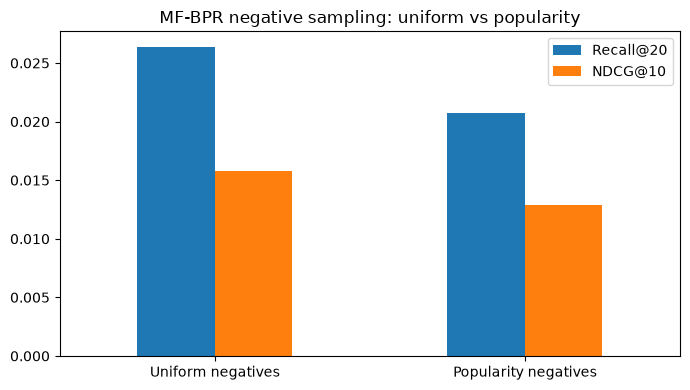

,Recall@20,Recall@50,NDCG@10,Coverage@20
Uniform negatives,0.0264,0.0347,0.0157,0.4135
Popularity negatives,0.0207,0.0256,0.0129,0.6847


In [14]:
ns = pd.DataFrame({'Uniform negatives': uniform_metrics,
                   'Popularity negatives': popularity_metrics}).T
ns_cols = ['Recall@20', 'Recall@50', 'NDCG@10', 'Coverage@20']
fig, ax = plt.subplots(figsize=(7, 4))
ns[['Recall@20', 'NDCG@10']].plot(kind='bar', ax=ax)
ax.set(title='MF-BPR negative sampling: uniform vs popularity')
ax.tick_params(axis='x', rotation=0); plt.tight_layout(); plt.show()
ns[ns_cols].round(4)

> **Interpretation.** On this dataset the two strategies **trade off** rather than one dominating:
>
> - **Uniform** negatives win on **accuracy** — Recall@20 **0.0264** vs **0.0207** and NDCG@10 **0.0157** vs **0.0129** (about **+22%**).
> - **Popularity** negatives win on **catalog coverage** — **0.68** vs **0.41**.
>
> The mechanism: popularity sampling repeatedly uses popular items *as negatives*, which pushes them down the ranking. That spreads recommendations across the long tail (higher coverage) but costs recall on a test set where popular items are often the correct answer. Uniform sampling never penalizes popular items, so it keeps them rankable (higher accuracy) at the expense of diversity.
>
> The rest of this notebook uses **popularity** sampling — the common default, favouring coverage and cold-start robustness — but this experiment shows **uniform** would be the better choice if pure top-K accuracy were the only objective. (Note our deployed retriever is the two-tower, which uses in-batch negatives; this comparison isolates the effect within MF-BPR.)